# 08_Cross_Validation.ipynb

# Section 1 — Introduction

Cross Validation is one of the **most important concepts in machine learning**. It provides a more reliable estimate of a model's performance than a single train-test split.

---

# What is Cross Validation?

Cross Validation is a model evaluation technique in which the dataset is split into **multiple training and validation sets**, and the model is trained and evaluated multiple times.

Instead of testing the model only once, we test it several times on different portions of the data.

---

# Why Do We Need Cross Validation?

With a normal train-test split:

```text
Dataset
    │
    ├── Train (80%)
    └── Test (20%)
```

The model's performance depends on **one particular split**.

For example:

```text
Random State = 42
Accuracy = 95%
```

If you change the split:

```text
Random State = 7
Accuracy = 91%
```

Different splits can produce different results.

Cross Validation reduces this dependency by evaluating the model on **multiple splits** and averaging the results.

---

# Mathematical Intuition

Suppose we have **100 samples**.

Using **5-Fold Cross Validation**:

```text
Fold 1 → Train on 80, Validate on 20
Fold 2 → Train on 80, Validate on 20
Fold 3 → Train on 80, Validate on 20
Fold 4 → Train on 80, Validate on 20
Fold 5 → Train on 80, Validate on 20
```

Every sample is:

* Used for training **4 times**
* Used for validation **1 time**

Final Score:

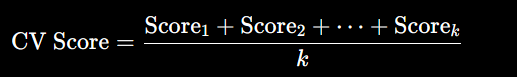

where (k) is the number of folds.

---

# K-Fold Cross Validation

The most common type is **K-Fold Cross Validation**.

Example with **5 folds**:

```text
Dataset

[ 1 ][ 2 ][ 3 ][ 4 ][ 5 ]
```

Iteration 1

```text
Test

[ 1 ]

Train

[ 2 ][ 3 ][ 4 ][ 5 ]
```

Iteration 2

```text
Train

[ 1 ]

Test

[ 2 ]

Train

[ 3 ][ 4 ][ 5 ]
```

Iteration 3

```text
Train

[ 1 ][ 2 ]

Test

[ 3 ]

Train

[ 4 ][ 5 ]
```

Iteration 4

```text
Train

[ 1 ][ 2 ][ 3 ]

Test

[ 4 ]

Train

[ 5 ]
```

Iteration 5

```text
Train

[ 1 ][ 2 ][ 3 ][ 4 ]

Test

[ 5 ]
```

Every fold becomes the validation set exactly once.

---

# Why is Cross Validation Better?

Suppose one train-test split gives:

```text
Accuracy = 97%
```

Was the model actually good?

Maybe.

Maybe not.

Cross Validation gives:

```text
Fold 1 = 95%

Fold 2 = 96%

Fold 3 = 94%

Fold 4 = 95%

Fold 5 = 96%
```

Average

```text
95.2%
```

This average is much more reliable than a single score.

---

# Advantages

| Advantage                              | Explanation                                            |
| -------------------------------------- | ------------------------------------------------------ |
| More reliable evaluation               | Uses multiple train-validation splits                  |
| Better use of data                     | Every sample is used for validation exactly once       |
| Reduces dependence on one random split | Performance is averaged across folds                   |
| Helps detect overfitting               | Large variation between folds may indicate instability |
| Works well with GridSearchCV           | Standard evaluation method for hyperparameter tuning   |

---

# Disadvantages

| Disadvantage                   | Explanation                                     |
| ------------------------------ | ----------------------------------------------- |
| Slower                         | Trains the model multiple times                 |
| More computationally expensive | Especially for large datasets or complex models |
| Not ideal for time series      | Standard K-Fold breaks temporal order           |

---

# When to Use

Use Cross Validation when:

* Comparing multiple models.
* Selecting hyperparameters.
* Working with small or medium-sized datasets.
* Reporting a reliable performance estimate.

---

# When NOT to Use

Avoid standard K-Fold when:

* Data is time-dependent (use `TimeSeriesSplit` instead).
* Training is extremely expensive and repeated fitting is impractical.
* You already have a very large independent test set and only need a quick evaluation.

---

# Applications

| Domain          | Example                             |
| --------------- | ----------------------------------- |
| Healthcare      | Compare disease prediction models   |
| Finance         | Evaluate credit risk models         |
| Marketing       | Compare customer churn classifiers  |
| NLP             | Evaluate text classification models |
| Computer Vision | Compare image classifiers           |

---

# Train-Test Split vs Cross Validation

| Train-Test Split       | Cross Validation                |
| ---------------------- | ------------------------------- |
| One split              | Multiple splits                 |
| One evaluation score   | Average of multiple scores      |
| Faster                 | Slower                          |
| Depends on one split   | More reliable                   |
| Good for quick testing | Good for final model comparison |

---

# Types of Cross Validation

| Method                | Use Case                                         |
| --------------------- | ------------------------------------------------ |
| K-Fold                | General-purpose regression/classification        |
| Stratified K-Fold     | Classification with class imbalance              |
| Leave-One-Out (LOOCV) | Very small datasets                              |
| Group K-Fold          | Grouped observations                             |
| TimeSeriesSplit       | Time-series data                                 |
| Repeated K-Fold       | More robust estimates through repeated splitting |

We'll focus on **K-Fold** and **Stratified K-Fold**, as they are the most commonly used in scikit-learn.

---

# Key Takeaways

* Cross Validation evaluates a model on **multiple train-validation splits**.
* It provides a **more reliable estimate** of model performance than a single train-test split.
* **K-Fold Cross Validation** is the most commonly used technique.
* Each sample is used for validation exactly once.
* The final score is the **average across all folds**.
* Cross Validation is the foundation of **GridSearchCV**, which you'll learn in the next notebook.

# 08_Cross_Validation.ipynb

# Section 2 — Import & Constructor

Unlike `Pipeline` or `LogisticRegression`, **Cross Validation is not a model**.

It is a **model evaluation technique**.

So there is:

* ❌ No estimator object
* ❌ No `.fit()` on Cross Validation itself
* ✅ Functions like `cross_val_score()`
* ✅ Splitter classes like `KFold` and `StratifiedKFold`

---

# Main Components

There are **three** important things you'll use:

| Component           | Purpose                                      |
| ------------------- | -------------------------------------------- |
| `cross_val_score()` | Performs Cross Validation and returns scores |
| `KFold`             | Defines how data is split                    |
| `StratifiedKFold`   | Splits while preserving class distribution   |

---

# Imports

```python
from sklearn.model_selection import (
    cross_val_score,
    KFold,
    StratifiedKFold
)
```

---

# 1. cross_val_score() ⭐⭐⭐⭐⭐

This is the most commonly used function.

It automatically:

* Splits the data
* Trains the model
* Validates the model
* Returns one score for each fold

---

## Syntax

```python
cross_val_score(
    estimator,
    X,
    y=None,
    *,
    groups=None,
    scoring=None,
    cv=None,
    n_jobs=None,
    verbose=0,
    fit_params=None,
    params=None,
    pre_dispatch='2*n_jobs',
    error_score=np.nan
)
```

We'll focus only on the parameters you'll actually use.

---

## Important Parameters

| Parameter   | Default | Description                    |
| ----------- | ------- | ------------------------------ |
| `estimator` | —       | Model or Pipeline to evaluate  |
| `X`         | —       | Features                       |
| `y`         | `None`  | Target values                  |
| `scoring`   | `None`  | Evaluation metric              |
| `cv`        | `None`  | Number of folds or CV splitter |
| `n_jobs`    | `None`  | Number of CPU cores            |

---

# estimator ⭐⭐⭐⭐⭐

The model to evaluate.

Example

```python
LogisticRegression()
```

or

```python
Pipeline(...)
```

Example

```python
scores = cross_val_score(
    estimator=pipe,
    X=X,
    y=y
)
```

---

# X

Feature matrix.

```python
X=X
```

Usually

```python
X_train
```

or

```python
X
```

---

# y

Target values.

```python
y=y
```

---

# scoring ⭐⭐⭐⭐⭐

Specifies **which metric** to evaluate.

Default

```python
None
```

means:

Use the estimator's default `score()` method.

Examples:

| Model              | Default Score |
| ------------------ | ------------- |
| LogisticRegression | Accuracy      |
| LinearRegression   | R² Score      |

---

## Common scoring values

### Classification

| Scoring       | Meaning   |
| ------------- | --------- |
| `"accuracy"`  | Accuracy  |
| `"precision"` | Precision |
| `"recall"`    | Recall    |
| `"f1"`        | F1 Score  |
| `"roc_auc"`   | ROC AUC   |

---

### Regression

| Scoring                         | Meaning  |
| ------------------------------- | -------- |
| `"r2"`                          | R² Score |
| `"neg_mean_absolute_error"`     | MAE      |
| `"neg_mean_squared_error"`      | MSE      |
| `"neg_root_mean_squared_error"` | RMSE     |

Notice:

```text
neg_
```

We'll discuss **why regression losses are returned as negative values** later.

---

Example

```python
scores = cross_val_score(
    estimator=pipe,
    X=X,
    y=y,
    scoring="accuracy"
)
```

---

# cv ⭐⭐⭐⭐⭐

Defines **how Cross Validation is performed**.

Three common options.

---

## Option 1

Integer

```python
cv=5
```

Means

```text
5-Fold Cross Validation
```

Internally

```python
KFold(n_splits=5)
```

or

```python
StratifiedKFold(n_splits=5)
```

depending on the estimator/problem type.

---

## Option 2

KFold object

```python
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

More control.

---

## Option 3

StratifiedKFold

```python
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Best for classification.

---

Example

```python
scores = cross_val_score(
    estimator=pipe,
    X=X,
    y=y,
    cv=5
)
```

---

# n_jobs

Controls parallel processing.

```python
n_jobs=None
```

means

Use one CPU core.

---

```python
n_jobs=-1
```

means

Use **all CPU cores**.

Useful for

* Large datasets
* Large models
* Large Grid Searches

---

Example

```python
scores = cross_val_score(
    estimator=pipe,
    X=X,
    y=y,
    cv=5,
    n_jobs=-1
)
```

---

# Return Value

Returns

```python
numpy.ndarray
```

Example

```python
scores = cross_val_score(...)
```

Output

```python
array([
0.97,
0.95,
0.98,
0.96,
0.97
])
```

Each value corresponds to **one fold**.

Average

```python
scores.mean()
```

---

# 2. KFold ⭐⭐⭐⭐

Creates a custom K-Fold splitter.

---

## Syntax

```python
KFold(
    n_splits=5,
    *,
    shuffle=False,
    random_state=None
)
```

---

## Important Parameters

| Parameter      | Default | Description                                              |
| -------------- | ------- | -------------------------------------------------------- |
| `n_splits`     | 5       | Number of folds                                          |
| `shuffle`      | False   | Shuffle data before splitting                            |
| `random_state` | None    | Seed for reproducibility (used only when `shuffle=True`) |

---

Example

```python
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Then

```python
cross_val_score(
    pipe,
    X,
    y,
    cv=kf
)
```

---

# 3. StratifiedKFold ⭐⭐⭐⭐⭐

Very similar to `KFold`.

Difference:

It preserves the class distribution in every fold.

---

Example

Dataset

```text
900 Class A

100 Class B
```

Normal KFold may create

```text
Fold 1

200 A

0 B
```

Bad split.

---

StratifiedKFold creates

```text
Fold 1

180 A

20 B
```

Much better.

---

## Syntax

```python
StratifiedKFold(
    n_splits=5,
    shuffle=False,
    random_state=None
)
```

Same parameters as `KFold`.

---

# Recommended Settings

### Regression

```python
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

---

### Classification

```python
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

---

# Constructor Summary

| Component           | Most Important Parameters                        |
| ------------------- | ------------------------------------------------ |
| `cross_val_score()` | `estimator`, `X`, `y`, `scoring`, `cv`, `n_jobs` |
| `KFold`             | `n_splits`, `shuffle`, `random_state`            |
| `StratifiedKFold`   | `n_splits`, `shuffle`, `random_state`            |

---

# ⭐ Interview Tip

**Q:** Why is `StratifiedKFold` preferred over `KFold` for classification?

**Answer:**

Because it preserves the **class distribution** in every fold. This produces more representative training and validation sets, especially when the dataset is imbalanced.


# 08_Cross_Validation.ipynb

# Section 3 — Methods & Attributes

Unlike `Pipeline` or `LogisticRegression`, Cross Validation does **not** have many methods or attributes because it is **primarily a function-based API**.

We'll cover:

1. `cross_val_score()`
2. `cross_validate()`
3. `cross_val_predict()`
4. Important attributes of `KFold` and `StratifiedKFold`

---

# 1. cross_val_score() ⭐⭐⭐⭐⭐

This is the most commonly used function.

It performs the entire cross-validation process and returns **one score per fold**.

---

## Example

```python
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    estimator=pipe,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy"
)
```

Output

```python
array([
0.97,
0.95,
0.96,
0.98,
0.97
])
```

---

## What does it return?

Each value is the score obtained on one validation fold.

| Fold   | Accuracy |
| ------ | -------- |
| Fold 1 | 0.97     |
| Fold 2 | 0.95     |
| Fold 3 | 0.96     |
| Fold 4 | 0.98     |
| Fold 5 | 0.97     |

Average

```python
scores.mean()
```

Output

```text
0.966
```

---

# 2. cross_validate() ⭐⭐⭐⭐

`cross_val_score()` returns **only one metric**.

What if you want:

* Accuracy
* Precision
* Recall
* F1

all at once?

Use `cross_validate()`.

---

## Import

```python
from sklearn.model_selection import cross_validate
```

---

## Example

```python
scores = cross_validate(
    estimator=pipe,
    X=X,
    y=y,
    cv=5,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ]
)
```

---

## Return Type

Dictionary

Example

```python
{
 'fit_time': ...,
 'score_time': ...,
 'test_accuracy': ...,
 'test_precision_macro': ...,
 'test_recall_macro': ...,
 'test_f1_macro': ...
}
```

Now you can access

```python
scores["test_accuracy"]

scores["test_f1_macro"]
```

---

# Why use cross_validate()?

| cross_val_score() | cross_validate()   |
| ----------------- | ------------------ |
| One metric        | Multiple metrics   |
| Returns array     | Returns dictionary |
| Simpler           | More flexible      |

---

# 3. cross_val_predict() ⭐⭐⭐⭐

Sometimes you don't want scores.

You want the **predictions** produced during cross-validation.

Use

```python
from sklearn.model_selection import cross_val_predict
```

---

Example

```python
pred = cross_val_predict(
    estimator=pipe,
    X=X,
    y=y,
    cv=5
)
```

Returns

```python
array([
1,
0,
1,
...
])
```

Notice

It returns

```text
Predictions
```

NOT

```text
Scores
```

---

## Why use it?

Useful when you want

* Confusion Matrix
* Classification Report
* ROC Curve

based on cross-validation predictions.

Example

```python
from sklearn.metrics import confusion_matrix

pred = cross_val_predict(...)

cm = confusion_matrix(
    y,
    pred
)
```

---

# KFold Methods

---

## split() ⭐⭐⭐⭐⭐

The most important method.

Syntax

```python
kf.split(X)
```

Returns

```text
Training indices

Validation indices
```

---

Example

```python
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5
)

for train_idx, test_idx in kf.split(X):

    print(train_idx)

    print(test_idx)
```

Output

```text
Train

[2 3 4 5 ...]

Test

[0 1]
```

Each iteration returns **different indices**.

---

## get_n_splits()

Returns

```text
Number of folds
```

Example

```python
kf.get_n_splits()
```

Output

```text
5
```

---

# StratifiedKFold Methods

Exactly the same methods.

```python
skf.split(X, y)

skf.get_n_splits()
```

Difference

`split()`

requires

```python
y
```

because it must preserve class distribution.

---

# KFold Attributes

Very few attributes.

| Attribute  | Description     |
| ---------- | --------------- |
| `n_splits` | Number of folds |

Example

```python
kf.n_splits
```

Output

```text
5
```

---

# StratifiedKFold Attributes

Same.

```python
skf.n_splits
```

---

# Complete Example

```python
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    estimator=pipe,
    X=X,
    y=y,
    cv=cv,
    scoring="accuracy"
)

print(scores)

print(scores.mean())
```

Output

```text
[0.97 0.95 0.96 0.98 0.97]

Mean

0.966
```

---

# Which One Should You Use?

| Goal                         | Function                    |
| ---------------------------- | --------------------------- |
| One evaluation metric        | `cross_val_score()`         |
| Multiple evaluation metrics  | `cross_validate()`          |
| Predictions for every sample | `cross_val_predict()`       |
| Custom splitting             | `KFold` / `StratifiedKFold` |

---

# Summary

## Functions

| Function              | Most Used? |
| --------------------- | ---------- |
| `cross_val_score()`   | ⭐⭐⭐⭐⭐      |
| `cross_validate()`    | ⭐⭐⭐⭐       |
| `cross_val_predict()` | ⭐⭐⭐⭐       |

---

## Splitter Methods

| Method           | Most Used? |
| ---------------- | ---------- |
| `split()`        | ⭐⭐⭐⭐⭐      |
| `get_n_splits()` | ⭐⭐⭐        |

---

## Attributes

| Attribute  | Importance |
| ---------- | ---------- |
| `n_splits` | ⭐⭐⭐        |

---

## ⭐ Interview Tip

**Q:** What is the difference between `cross_val_score()`, `cross_validate()`, and `cross_val_predict()`?

**Answer:**

* **`cross_val_score()`** → Returns **one score per fold** for a single metric.
* **`cross_validate()`** → Returns **multiple metrics** (and timing information) in a dictionary.
* **`cross_val_predict()`** → Returns the **predicted labels (or values)** for every sample using cross-validation.

This completes **Section 3 — Methods & Attributes**.
